# Очистка чертежа: классификация штрихов и поиск наконечников

| шаг | что делает | результат |
|---|---|---|
| 1 | загрузка, единый масштаб | `img_bgr` |
| 2 | детекция текста (PP-OCRv5 det) | `text_region` |
| 3 | бинаризация | `binary`, `fg` |
| 4 | толщина штриха через distance transform | `thickness_map`, `t_axis` |
| 5 | граф скелета, текстовые рёбра | `graph`, `is_text_edge` |
| 6 | классы толщины, KMeans **без текстовых рёбер** | `cls_img` |
| 7 | класс ребра по большинству голосов | `cls_vote` |
| 8 | удаление тонких линий и текста | `mask_thick` |
| 9 | наконечники как пики ширины | `mask_clean` |

Текст ищется не ради самого текста, а чтобы буквы не смещали распределение толщин, по которому
KMeans ставит границы классов. Поэтому граф строится **до** кластеризации: чистить выборку надо
целыми рёбрами, а не пикселями внутри прямоугольника.

Параметры задаются слайдерами. Каждая такая ячейка кончается объектом `ui_*`, результат лежит
в `ui_*.result` и распаковывается в начале следующей ячейки. Подвинул слайдер — перезапусти
ячейки ниже.

## 1. Загрузка и масштаб

Импорты и палитра классов — единственное место в ноутбуке, где что-то импортируется.

In [1]:
from itertools import combinations
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from ipywidgets import Dropdown, FloatSlider, IntSlider, interactive
from matplotlib import pyplot as plt
from matplotlib.collections import LineCollection
from scipy.sparse import coo_matrix
from scipy.sparse.csgraph import connected_components
from scipy.spatial import cKDTree
from skan import Skeleton, summarize
from skimage.morphology import skeletonize
from sklearn.cluster import KMeans

PALETTE = [(70, 130, 255), (60, 200, 90), (255, 190, 40), (255, 70, 70), (200, 80, 255), (0, 220, 220)]

Список файлов датасета.

In [2]:
folder = Path("/mnt/data/datasets/Сравнение чертежей/Эскизы датасет")
files = sorted(folder.glob("*.jpg"))

print(f"файлов: {len(files)}")

файлов: 21


Приводим длинную сторону к единому размеру — это **единственный** ресайз пайплайна.

Вверх бикубикой: она восстанавливает по серой кайме вокруг штриха плавный градиент, порог режет
край субпиксельно, и толщины перестают слипаться при квантовании distance transform. Вниз
`INTER_AREA`. Само по себе увеличение классы не разводит (силуэт инвариантен к умножению всех
толщин на константу) — работает именно де-квантизация.

In [3]:
def load_image(file_path):
    """Загрузка изображения в формате BGR из файла."""
    data = np.fromfile(str(file_path), dtype=np.uint8)
    image = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if image is None:
        raise ValueError(f"Could not load image from {file_path}")
    return image


def resize_det_image(image, max_size=4000):
    """Приводит длинную сторону к max_size (вверх или вниз), потолок — 4000."""
    max_size = min(max_size, 4000)
    height, width = image.shape[:2]
    side = max(height, width)
    if side == max_size:
        return image

    k = max_size / float(side)
    interp = cv2.INTER_AREA if k < 1 else cv2.INTER_CUBIC
    return cv2.resize(image, (round(width * k), round(height * k)), interpolation=interp)

In [ ]:
def run_load_image(idx):
    """Загрузка и изменение размера изображения по индексу."""
    path = files[idx]
    img_bgr = load_image(path)
    h, w = img_bgr.shape[:2]
    print(f"[{idx}] {path.stem} — {w}x{h}")
    plt.figure(figsize=(16, 8))
    plt.imshow(img_bgr[..., ::-1])  # BGR to RGB
    plt.axis("off")
    plt.show()
    return img_bgr


ui_load = interactive(
    run_load_image,
    idx=Dropdown(
        options=[(f"[{i}] {f.stem}", i) for i, f in enumerate(files)],
        value=6,
        description="файл",
    ),
)
ui_load

interactive(children=(Dropdown(description='файл', index=6, options=(('[0] 1', 0), ('[1] 10', 1), ('[2] 11', 2…

## 2. Детекция текста

Цель — не удалить текст, а исключить его из выборки, по которой оцениваются границы классов
толщины в шаге 5. Поэтому маска может быть грубой: мы ничего не стираем, а только не учитываем.

Препроцессинг. DBNet требует размер, кратный 32; добираем его **паддингом белым**, а не ресайзом,
чтобы масштаб остался ровно 1.0 и маска легла на штрихи попиксельно. Нормализация — из
`PP-OCRv5_server_det.yml`: scale 1/255, ImageNet mean/std.

In [5]:
def pad_to_stride(img):
    """Добавление паддинга к изображению так, чтобы его размеры были кратны 32."""
    h, w = img.shape[:2]
    ph, pw = (-h) % 32, (-w) % 32
    if ph == 0 and pw == 0:
        return img, 0, 0
    return cv2.copyMakeBorder(img, 0, ph, 0, pw, cv2.BORDER_CONSTANT, value=(255,) * 3), ph, pw


def to_blob(img):
    """Преобразование изображения в blob для подачи в нейросеть."""
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406], dtype=np.float32)
    std = np.array([0.229, 0.224, 0.225], dtype=np.float32)
    return ((rgb - mean) / std).transpose(2, 0, 1)[np.newaxis, ...]

In [6]:
img_bgr = ui_load.result

In [7]:
img_det, pad_h, pad_w = pad_to_stride(img_bgr)
blob = to_blob(img_det)

h, w = img_bgr.shape[:2]
dh, dw = img_det.shape[:2]
print(f"{w}x{h} -> {dw}x{dh} | добавлено строк {pad_h}, столбцов {pad_w} | h%32={dh % 32} w%32={dw % 32}")
print(f"оригинал не тронут: {np.array_equal(img_det[:h, :w], img_bgr)}")
print(f"blob {blob.shape} {blob.dtype} | min {blob.min():.3f} max {blob.max():.3f} | {blob.nbytes / 1024**2:.0f} MB")

6819x3378 -> 6848x3392 | добавлено строк 14, столбцов 29 | h%32=0 w%32=0
оригинал не тронут: True
blob (1, 3, 3392, 6848) float32 | min -2.118 max 2.640 | 266 MB


Прогон сети и обрезка полосы паддинга. Карта вероятностей `prob` совпадает с `img_bgr` попиксельно.

In [8]:
import onnxruntime as ort

det_session = ort.InferenceSession("./models/PP-OCRv5_server_det_infer.onnx")
input_name = det_session.get_inputs()[0].name
print(f"вход: {input_name} | {det_session.get_inputs()[0].shape}")

вход: x | ['DynamicDimension.0', 3, 'DynamicDimension.1', 'DynamicDimension.2']


In [9]:
def run_detection(blob):
    """Запуск детекции на изображении."""
    outputs = det_session.run(None, {input_name: blob})
    return outputs[0]  # предполагаем, что первый выход - это маска детекции


def process_detection_output(outputs, pad_h, pad_w, target_shape=None):
    """Снимает паддинг и (опционально) возвращает карту в разрешение оригинала."""
    h, w = outputs.shape[-2:]
    outputs = outputs[0, 0, : h - pad_h, : w - pad_w]

    if target_shape is not None:
        h0, w0 = target_shape[:2]
        interp = cv2.INTER_AREA if outputs.shape[0] > h0 else cv2.INTER_LINEAR
        outputs = cv2.resize(outputs.astype(np.float32), (w0, h0), interpolation=interp)

    return outputs


def multiscale_detection(image, scales=[640, 1600, 2600]) -> np.ndarray:
    """Запуск детекции на изображении с использованием нескольких масштабов."""
    maps = []
    for scale in scales:
        img_rescaled = resize_det_image(image, max_size=scale)
        print(f"размер {img_rescaled.shape[1]}x{img_rescaled.shape[0]}")
        img_det, pad_h, pad_w = pad_to_stride(img_rescaled)
        blob = to_blob(img_det)
        outputs = run_detection(blob)
        # Убираем паддинг из выхода
        m = process_detection_output(outputs, pad_h, pad_w, target_shape=image.shape)
        maps.append(m)
    return np.stack(maps)

In [10]:
scales = [320, 640, 2000]
maps = multiscale_detection(img_bgr, scales=scales)
print(f"stack: {maps.shape}, {maps.dtype}")

размер 320x159
размер 640x317
размер 2000x991
stack: (3, 3378, 6819), float32


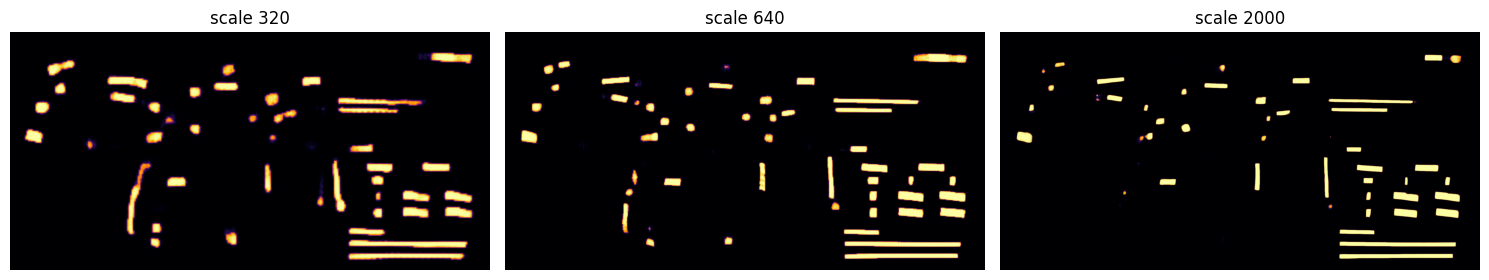

In [11]:
fig, axes = plt.subplots(1, len(maps), figsize=(5 * len(maps), 5))
for ax, m, s in zip(axes, maps, scales, strict=True):
    ax.imshow(m, cmap="inferno", vmin=0, vmax=1)
    ax.set_title(f"scale {s}")
    ax.axis("off")
plt.tight_layout()
plt.show()

In [12]:
def classify_maps(maps: np.ndarray, method: str = "mean", thr: float = 0.3) -> np.ndarray:
    """Стек карт вероятностей (S, H, W) -> бинарная маска (H, W) uint8 {0, 255}."""
    prob = {
        "max": maps.max,
        "mean": maps.mean,
        "min": maps.min,
        "median": lambda axis: np.median(maps, axis=axis),
    }[method](axis=0)
    return prob, ((prob > thr) * 255).astype(np.uint8)


prob, mask = classify_maps(maps, method="mean", thr=0.3)
print(f"prob: {prob.shape} {prob.dtype} min={prob.min():.3f} max={prob.max():.3f}")
print(f"mask: {(mask > 0).mean() * 100:.2f}% пикселей, компонент: {cv2.connectedComponents(mask)[0] - 1}")


prob: (3378, 6819) float32 min=0.000 max=1.000
mask: 6.04% пикселей, компонент: 57


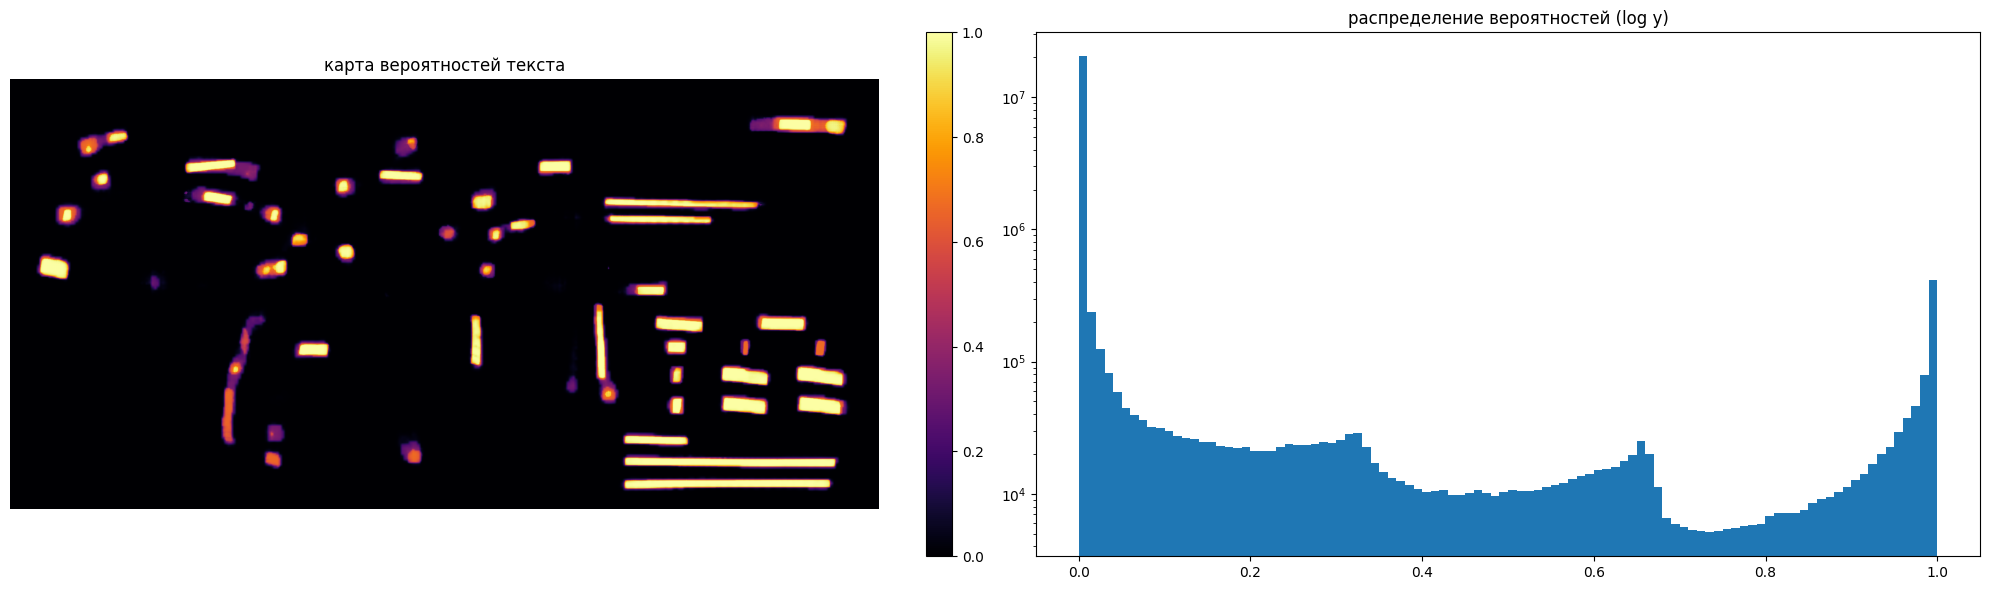

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(20, 6))
im = ax[0].imshow(prob, cmap="inferno", vmin=0, vmax=1)
ax[0].set_title("карта вероятностей текста")
ax[0].axis("off")
plt.colorbar(im, ax=ax[0], fraction=0.03)
ax[1].hist(prob.ravel(), bins=100, log=True)
ax[1].set_title("распределение вероятностей (log y)")
plt.tight_layout()
plt.show()

Кандидаты по логике `DBPostProcess`: контуры бинарной карты, `minAreaRect`, **средняя вероятность
внутри прямоугольника**. Порог `thresh` отвечает только за связность, решение принимает
`box_thresh` по этой средней. Площадь кандидата тут не участвует вообще.

In [14]:
def box_score(prob, box):
    """Средняя вероятность внутри четырёхугольника — score из DBPostProcess."""
    hh, ww = prob.shape[:2]
    b = box.copy()
    xmin, xmax = np.clip([np.floor(b[:, 0].min()), np.ceil(b[:, 0].max())], 0, ww - 1).astype(np.int32)
    ymin, ymax = np.clip([np.floor(b[:, 1].min()), np.ceil(b[:, 1].max())], 0, hh - 1).astype(np.int32)
    m = np.zeros((ymax - ymin + 1, xmax - xmin + 1), dtype=np.uint8)
    b[:, 0] -= xmin
    b[:, 1] -= ymin
    cv2.fillPoly(m, b.reshape(1, -1, 2).astype(np.int32), 1)
    return cv2.mean(prob[ymin : ymax + 1, xmin : xmax + 1], m)[0]


def db_candidates(prob, thresh, box_thresh, min_size, max_candidates=1000):
    """Только отбор кандидатов. Маска строится отдельно — чтобы отбор можно было смотреть сам по себе."""
    cnts, _ = cv2.findContours((prob > thresh).astype(np.uint8), cv2.RETR_LIST, cv2.CHAIN_APPROX_SIMPLE)
    rows = []
    for c in cnts[:max_candidates]:
        rect = cv2.minAreaRect(c)
        (rw, rh) = rect[1]
        area, perim = cv2.contourArea(c), cv2.arcLength(c, True)
        rows.append(
            dict(
                score=box_score(prob, cv2.boxPoints(rect)),
                sside=min(rw, rh),
                lside=max(rw, rh),
                area=area,
                perim=perim,
                fill=area / (rw * rh) if rw * rh else 0.0,
                cnt=c,
            )
        )
    df = pd.DataFrame(rows)
    if len(df):
        df["keep"] = (df.score >= box_thresh) & (df.sside >= min_size) & (df.perim > 0)
    return df, len(cnts)


def show_candidates(thresh, box_thresh, min_size):
    df, n_all = db_candidates(prob, thresh, box_thresh, min_size)
    if n_all > 1000:
        print(f"ВНИМАНИЕ: контуров {n_all}, лимит 1000 обрезал список")
    if not len(df):
        print("кандидатов нет")
        return df

    print(f"кандидатов {len(df)} | принято {int(df.keep.sum())} | отброшено {int((~df.keep).sum())}")
    print("\n5 крупнейших по площади:")
    print(df.drop(columns="cnt").sort_values("area", ascending=False).head(5).round(3).to_string())

    fig, ax = plt.subplots(1, 2, figsize=(18, 5))
    ax[0].hist(df.score, bins=40)
    ax[0].axvline(box_thresh, color="r", ls="--")
    ax[0].set_title("score кандидатов")
    ax[1].scatter(df.area, df.score, s=14, c=np.where(df.keep, "green", "red"))
    ax[1].axhline(box_thresh, color="r", ls="--")
    ax[1].set_xscale("log")
    ax[1].set_xlabel("площадь, px (log)")
    ax[1].set_ylabel("score")
    ax[1].set_title("разделяет score, а не площадь")
    plt.tight_layout()
    plt.show()
    return df


ui_cand = interactive(
    show_candidates,
    thresh=FloatSlider(value=0.3, min=0.05, max=0.9, step=0.05, continuous_update=False, description="thresh"),
    box_thresh=FloatSlider(value=0.4, min=0.1, max=0.95, step=0.05, continuous_update=False, description="box_thresh"),
    min_size=IntSlider(value=3, min=0, max=30, step=1, continuous_update=False, description="min_size"),
)
ui_cand

interactive(children=(FloatSlider(value=0.3, continuous_update=False, description='thresh', max=0.9, min=0.05,…

Маска текстовой области: контур каждого принятого ядра раздувается на `d = area·ratio/perimeter`.
Раздуваем сам контур, а не описанный прямоугольник, — форма идёт вдоль наклонных надписей и
захватывает меньше лишнего. Бери с запасом: лишний захват линии стоит дёшево, пропущенный текст — дорого.

In [15]:
df_cand = ui_cand.result
assert df_cand is not None and len(df_cand), "кандидатов нет — ослабь thresh в предыдущей ячейке"


def build_region(unclip_ratio):
    region = np.zeros((h, w), np.uint8)
    kept = df_cand[df_cand.keep]
    for c, area, perim in zip(kept.cnt, kept.area, kept.perim):
        d = int(round(area * unclip_ratio / perim))
        x, y, bw, bh = cv2.boundingRect(c)
        pad = d + 2
        x0, y0 = max(0, x - pad), max(0, y - pad)
        x1, y1 = min(w, x + bw + pad), min(h, y + bh + pad)

        sub = np.zeros((y1 - y0, x1 - x0), np.uint8)
        cv2.drawContours(sub, [c - np.array([[x0, y0]])], -1, 255, cv2.FILLED)
        if d > 0:
            dist = cv2.distanceTransform(np.where(sub > 0, 0, 255).astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
            sub = np.where((dist <= d) | (sub > 0), 255, 0).astype(np.uint8)
        region[y0:y1, x0:x1] = np.maximum(region[y0:y1, x0:x1], sub)

    core_u8 = np.zeros((h, w), np.uint8)
    for c in kept.cnt:
        cv2.drawContours(core_u8, [c], -1, 255, cv2.FILLED)
    core_px = core_u8 > 0

    print(f"принятых ядер {len(kept)} | ядро {core_px.mean() * 100:.3f}% -> область {(region > 0).mean() * 100:.3f}%")

    overlay = img_bgr.copy()
    overlay[region > 0] = (0, 0, 255)
    overlay[core_px] = (0, 140, 255)
    blend = cv2.addWeighted(overlay, 0.45, img_bgr, 0.55, 0)

    plt.figure(figsize=(18, 10))
    plt.imshow(cv2.cvtColor(blend, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title(f"оранжевое — ядро сети, красное — раздутие на unclip {unclip_ratio}")
    plt.show()
    return region > 0


ui_region = interactive(
    build_region,
    unclip_ratio=FloatSlider(value=1.5, min=0.0, max=4.0, step=0.1, continuous_update=False, description="unclip"),
)
ui_region

interactive(children=(FloatSlider(value=1.5, continuous_update=False, description='unclip', max=4.0), Output()…

## 3. Бинаризация

Штрих тёмный на светлом, отсюда `THRESH_BINARY_INV`. Размытие гасит зерно JPEG: без него тонкие
линии рвутся, а разрыв плодит ложные концы в графе. Otsu ставит порог по гистограмме сам;
ручной режим нужен на сканах с неровным фоном.

In [16]:
def resize_image(image, scale=2.0):
    """Изменение размера изображения с сохранением пропорций."""
    h, w = image.shape[:2]
    new_w, new_h = int(w * scale), int(h * scale)
    return cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)


def to_gray(image):
    """Преобразование изображения в оттенки серого."""
    return cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)


def otsu_image(image, threshold=0):
    """Преобразование изображения в бинарное с использованием заданного порога."""
    thr, fg = cv2.threshold(image, threshold, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    return fg, thr

In [17]:
text_region = ui_region.result
SCALE = 2.0
resized = resize_image(img_bgr, scale=SCALE)
text_region_resized = resize_image(text_region.astype(np.uint8) * 255, scale=SCALE) > 0
text_region = text_region_resized.astype(bool)
gray = to_gray(resized)


def binarize():
    blurred = cv2.bilateralFilter(gray, d=11, sigmaColor=15, sigmaSpace=15)
    binary, thr = otsu_image(blurred)

    fg = binary > 0

    plt.figure(figsize=(16, 8))
    plt.imshow(fg, cmap="gray")
    plt.axis("off")
    plt.title(f"бинаризация Otsu | порог {thr:.0f}")
    plt.show()
    return fg, binary


ui_binary = interactive(binarize)
ui_binary


interactive(children=(Output(),), _dom_classes=('widget-interact',))

## 4. Толщина штриха

`distanceTransform` даёт расстояние до фона, то есть половину локальной ширины. Значения снимаем
**только с медиальной оси**: на краях штриха оценка занижена по построению и смазывает гистограмму.
Параметров нет; ячейка дорогая, поэтому и вынесена отдельно от подбора классов.

In [18]:
DIRS = np.array([(0, 1), (1, 1), (1, 0), (1, -1)])


def chord(fg, y, x, dy, dx):
    """Концы и длина пробега переднего плана через точку в направлении (dy, dx)."""
    h, w = fg.shape
    ends = []
    for s in (1, -1):
        yy, xx = y, x
        while True:
            ny, nx = yy + s * dy, xx + s * dx
            if not (0 <= ny < h and 0 <= nx < w) or not fg[ny, nx]:
                break
            yy, xx = ny, nx
        ends.append((yy, xx))
    (y0, x0), (y1, x1) = ends
    return ends, np.hypot(y1 - y0, x1 - x0) + 1


def seed_at(fg, y, x):
    """Минимальная из четырёх хорд даёт ширину, её середина — ось, нормаль к ней — направление линии."""
    res = [chord(fg, y, x, dy, dx) for dy, dx in DIRS]
    i = int(np.argmin([r[1] for r in res]))
    (y0, x0), (y1, x1) = res[i][0]
    return (y0 + y1) // 2, (x0 + x1) // 2, res[i][1], *DIRS[(i + 2) % 4]


def row_seeds(fg, step):
    """Скан каждой step-й строки: середина каждого горизонтального пробега — кандидат в затравку."""
    out = []
    for y in range(0, fg.shape[0], step):
        edges = np.flatnonzero(np.diff(np.r_[0, fg[y].astype(np.int8), 0]))
        for x0, x1 in edges.reshape(-1, 2):
            out.append(seed_at(fg, y, (x0 + x1 - 1) // 2))
    return pd.DataFrame(out, columns=["y", "x", "w", "dy", "dx"])


def seeds(fg, step):
    """Скан по строкам и по столбцам: горизонтали ловит второй проход, вертикали — первый."""
    a = row_seeds(fg, step)
    b = row_seeds(np.ascontiguousarray(fg.T), step).rename(columns={"y": "x", "x": "y", "dy": "dx", "dx": "dy"})
    return pd.concat([a, b], ignore_index=True).drop_duplicates(subset=["y", "x"], ignore_index=True)

In [ ]:
fg, binary = ui_binary.result


def show_seeds(step, w_max):
    """Точки затравок, цвет — ширина, штрих — направление линии."""
    s = seeds(fg, step)  # было row_seeds(fg, step)
    print(
        f"затравок {len(s)} | ширина: p10 {s.w.quantile(0.1):.1f}, медиана {s.w.median():.1f}, p90 {s.w.quantile(0.9):.1f}, max {s.w.max():.1f}"
    )
    print(s.w.value_counts().sort_index().head(8).to_string())

    fig, ax = plt.subplots(figsize=(18, 10))
    ax.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY), cmap="gray", alpha=0.4)
    sc = ax.scatter(s.x, s.y, c=s.w.clip(upper=w_max), cmap="turbo", s=6, vmin=1, vmax=w_max)
    ax.quiver(s.x, s.y, s.dx, s.dy, angles="xy", scale_units="xy", scale=0.15, color="k", width=0.001, alpha=0.5)
    ax.figure.colorbar(sc, ax=ax, fraction=0.03, label="ширина, px")
    ax.axis("off")
    ax.set_title(f"затравки: скан каждой {step}-й строки")
    plt.show()
    return s


ui_seeds = interactive(
    show_seeds,
    step=IntSlider(value=8, min=2, max=32, step=2, continuous_update=False, description="шаг скана"),
    w_max=FloatSlider(value=10.0, min=3.0, max=30.0, step=1.0, continuous_update=False, description="шкала до"),
)
ui_seeds

interactive(children=(IntSlider(value=8, continuous_update=False, description='шаг скана', max=32, min=2, step…

In [ ]:
def section(fg, p, n, w_max):
    """Концы и длина поперечного сечения через точку p вдоль нормали n."""
    h, w = fg.shape
    ends = []
    for s in (1, -1):
        q = p
        for i in range(1, int(w_max) + 1):
            c = p + s * i * n
            y, x = int(round(c[0])), int(round(c[1]))
            if not (0 <= y < h and 0 <= x < w) or not fg[y, x]:
                break
            q = c
        ends.append(q)
    return ends[0], ends[1], float(np.hypot(*(ends[0] - ends[1]))) + 1


def walk(fg, visited, p, d, par):
    """Одна ветвь трассы. Стоп: скачок ширины, поворот больше порога, конец штриха, чужая трасса."""
    pts, ws = [p], []
    cos_lim = np.cos(np.radians(par["turn"]))
    while True:
        n = np.array([-d[1], d[0]])
        a, b, w = section(fg, pts[-1] + par["step"] * d, n, par["w_max"])
        if w < 1:
            break
        if ws:
            ref = np.median(ws[-5:])
            if abs(w - ref) > max(par["w_tol"], (par["w_k"] - 1) * ref):
                break

        c = (a + b) / 2
        d_new = c - pts[max(0, len(pts) - par["look"] - 1)]
        if np.hypot(*d_new) < 1e-6:
            break
        d_new /= np.hypot(*d_new)
        if d_new @ d < cos_lim:
            break

        y, x = int(round(c[0])), int(round(c[1]))
        if not (0 <= y < fg.shape[0] and 0 <= x < fg.shape[1]) or not fg[y, x] or visited[y, x]:
            break
        pts.append(c)
        ws.append(w)
        d = d_new
    return np.array(pts), np.array(ws)


def trace_all(fg, sd, par, min_pts=3):
    """Трассы из всех затравок. Пройденное помечается, чтобы соседние затравки не плодили дубли."""
    visited = np.zeros(fg.shape, bool)
    out = []
    for y, x, w0, dy, dx in sd.itertuples(index=False):
        if visited[int(y), int(x)]:
            continue
        d = np.array([float(dy), float(dx)])
        d /= np.hypot(*d)
        p = np.array([float(y), float(x)])
        f_pts, f_w = walk(fg, visited, p, d, par)
        b_pts, b_w = walk(fg, visited, p, -d, par)

        pts = np.vstack([b_pts[::-1], f_pts[1:]]) if len(b_pts) > 1 else f_pts
        ws = np.r_[b_w[::-1], f_w]
        if len(pts) < min_pts:
            continue
        wm = float(np.median(ws)) if len(ws) else float(w0)
        cv2.polylines(visited.view(np.uint8), [pts[:, ::-1].round().astype(np.int32)], False, 1, max(1, round(wm)))
        out.append((pts, ws, wm))
    return out, visited

In [ ]:
def run_trace(step, w_tol, w_k, turn):
    """Трассировка от затравок ui_seeds. Цвет случайный: смена цвета вдоль линии = трасса оборвалась."""
    sd = ui_seeds.result
    par = dict(step=step, w_tol=w_tol, w_k=w_k, turn=turn, look=3, w_max=sd.w.max())
    tr, visited = trace_all(fg, sd, par)

    length = np.array([np.hypot(*np.diff(p, axis=0).T).sum() for p, _, _ in tr])
    width = np.array([w for _, _, w in tr])
    print(f"затравок {len(sd)} -> трасс {len(tr)} | покрытие штрихов {(visited & fg).sum() / fg.sum():.1%}")
    print(
        f"длина: медиана {np.median(length):.0f}, p90 {np.percentile(length, 90):.0f}, max {length.max():.0f} px | длиннее 100 px: {int((length > 100).sum())}"
    )
    print(
        f"ширина: p10 {np.percentile(width, 10):.1f}, медиана {np.median(width):.1f}, p90 {np.percentile(width, 90):.1f}"
    )

    fig, ax = plt.subplots(figsize=(18, 10))
    ax.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY), cmap="gray", alpha=0.35)
    ax.add_collection(
        LineCollection(
            [p[:, ::-1] for p, _, _ in tr], colors=plt.cm.hsv(np.random.default_rng(0).random(len(tr))), linewidths=1.6
        )
    )
    ax.axis("off")
    ax.set_title(f"трассы: шаг {step} px | скачок ширины > {w_k}x или {w_tol} px | поворот > {turn}°")
    plt.show()
    return tr, visited


ui_trace = interactive(
    run_trace,
    step=FloatSlider(value=2.0, min=1.0, max=6.0, step=0.5, continuous_update=False, description="шаг, px"),
    w_tol=FloatSlider(value=1.5, min=0.5, max=5.0, step=0.5, continuous_update=False, description="допуск, px"),
    w_k=FloatSlider(value=1.5, min=1.1, max=3.0, step=0.1, continuous_update=False, description="скачок, x"),
    turn=FloatSlider(value=15.0, min=5.0, max=60.0, step=1.0, continuous_update=False, description="поворот, °"),
)
ui_trace

interactive(children=(FloatSlider(value=2.0, continuous_update=False, description='шаг, px', max=6.0, min=1.0,…

In [93]:
def path_thickness(skeleton, dist, trim=0.25):
    """Толщина = медиана (2r-1) по срединной части пути: узлы и концы отброшены."""
    n_px = np.diff(skeleton.paths.indptr)
    pid = np.repeat(np.arange(skeleton.n_paths), n_px)
    pos = np.arange(len(pid)) - np.repeat(skeleton.paths.indptr[:-1], n_px)
    keep = (pos >= trim * np.repeat(n_px, n_px)) & (pos < (1 - trim) * np.repeat(n_px, n_px))

    rc = skeleton.coordinates[skeleton.paths.indices].astype(int)
    vals = 2 * dist[rc[:, 0], rc[:, 1]] - 1
    med = pd.Series(vals[keep]).groupby(pid[keep]).median()
    return med.reindex(np.arange(skeleton.n_paths)).to_numpy()  # длина всегда n_paths


def area_thickness(owner, skeleton, summary):
    """Толщина = площадь принадлежащих ребру пикселей / длина ребра."""
    area = np.bincount(owner[owner >= 0], minlength=skeleton.n_paths).astype(float)
    return area / np.maximum(summary["branch-distance"].to_numpy(), 1.0)


def path_id_image(skeleton, shape):
    """Карта пикселей скелета -> индекс пути (-1 вне скелета)."""
    img = np.full(shape, -1, dtype=np.int32)
    rc = skeleton.coordinates[skeleton.paths.indices].astype(int)
    img[rc[:, 0], rc[:, 1]] = np.repeat(np.arange(skeleton.n_paths), np.diff(skeleton.paths.indptr))
    return img


def owner_image(pid_img, fg):
    """Каждый пиксель переднего плана относим к ближайшему пути скелета (-1 вне штрихов)."""
    _, lbl = cv2.distanceTransformWithLabels(
        (pid_img < 0).astype(np.uint8), cv2.DIST_L2, cv2.DIST_MASK_PRECISE, labelType=cv2.DIST_LABEL_PIXEL
    )
    on_skel = pid_img >= 0
    lut = np.full(int(lbl.max()) + 1, -1, dtype=np.int32)
    lut[lbl[on_skel]] = pid_img[on_skel]
    return np.where(fg, lut[lbl], -1)


In [94]:
def ink_map(gray, fg, skel, dist):
    """Мягкая «чернильность» 0..1. Бумага оценивается локально, поэтому неровный тон не мешает."""
    k = 2 * int(3 * np.median(dist[skel])) + 1  # ядро заведомо шире любого штриха
    paper = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, np.ones((k, k), np.uint8)).astype(np.float32)
    ink_level = float(np.percentile(gray[fg], 5))
    return np.clip((paper - gray) / np.maximum(paper - ink_level, 1.0), 0.0, 1.0), k


def equivalent_thickness(ink, owner_ink, n_paths, branch_len):
    """Эквивалентная ширина ребра = весь собранный им объём чернил / длина. Порога не содержит."""
    sel = owner_ink >= 0
    total = np.bincount(owner_ink[sel], weights=ink[sel], minlength=n_paths)
    return total / np.maximum(branch_len, 1.0)


In [95]:
fg, binary = ui_binary.result
skel = skeletonize(fg)
dist = cv2.distanceTransform(binary, cv2.DIST_L2, cv2.DIST_MASK_PRECISE)

skeleton = Skeleton(skel)
summary = summarize(skeleton, separator="-")
owner = owner_image(path_id_image(skeleton, skel.shape), fg)
thickness = path_thickness(skeleton, dist)
summary["thickness"] = thickness
summary["thickness_area"] = area_thickness(owner, skeleton, summary)

print(f"путей {skeleton.n_paths} | покрыто штрихов {(owner >= 0).sum() / fg.sum():.1%}")
print(summary[["branch-distance", "branch-type", "thickness", "thickness_area"]].describe().round(2))

путей 1224 | покрыто штрихов 100.0%
       branch-distance  branch-type  thickness  thickness_area
count          1224.00      1224.00    1224.00         1224.00
mean            187.58         1.50      22.38           24.07
std             281.33         0.72       8.87           19.67
min               1.00         0.00       3.00            0.00
25%              36.79         1.00      15.12           14.59
50%             103.10         2.00      21.36           21.70
75%             205.79         2.00      27.64           27.85
max            3055.97         3.00      64.01          358.50


In [96]:
def text_ratio(skeleton, text_region):
    """Доля пикселей каждого пути, попавших в текстовые области. -> (n_paths,)"""
    rc = skeleton.coordinates[skeleton.paths.indices].astype(int)
    pid = np.repeat(np.arange(skeleton.n_paths), np.diff(skeleton.paths.indptr))
    return pd.Series(text_region[rc[:, 0], rc[:, 1]]).groupby(pid).mean().to_numpy()


t_ratio = text_ratio(skeleton, text_region)
is_text = t_ratio > 0.5

print(f"текстовых рёбер {is_text.sum()}/{skeleton.n_paths} ({is_text.mean():.1%})")
print(f"их доля длины {summary.loc[is_text, 'branch-distance'].sum() / summary['branch-distance'].sum():.1%}")
print(
    f"толщина: текст {np.nanmedian(thickness[is_text]):.2f} px | остальное {np.nanmedian(thickness[~is_text]):.2f} px"
)

текстовых рёбер 677/1224 (55.3%)
их доля длины 46.2%
толщина: текст 17.00 px | остальное 25.00 px


In [97]:
BT = {0: "конец–конец (изолят)", 1: "узел–конец (шпора)", 2: "узел–узел", 3: "цикл"}

seg_xy = [skeleton.path_coordinates(i)[:, ::-1] for i in range(skeleton.n_paths)]
bounds = np.array([[s[:, 0].min(), s[:, 0].max(), s[:, 1].min(), s[:, 1].max()] for s in seg_xy])
path_color = plt.cm.hsv(np.random.default_rng(0).random(skeleton.n_paths))

L = summary["branch-distance"].to_numpy()
bt = summary["branch-type"].to_numpy()
src, dst = summary["node-id-src"].to_numpy(), summary["node-id-dst"].to_numpy()
deg = np.bincount(np.concatenate([src, dst]), minlength=len(skeleton.coordinates))
node_rc = skeleton.coordinates  # id узла — это индекс в coordinates
t_med = float(np.nanmedian(thickness))
short = L < 2 * t_med


def branch_stats():
    """Рёбра по типу: сколько, какой длины, сколько коротких."""
    g = pd.DataFrame({"bt": bt, "len": L, "short": short}).groupby("bt")
    tab = pd.DataFrame(
        {"n": g.size(), "len_sum": g["len"].sum(), "len_med": g["len"].median(), "n_short": g["short"].sum()}
    )
    tab["len_share"] = tab.len_sum / L.sum()
    tab.index = [BT.get(i, i) for i in tab.index]
    return tab


def report_skeleton():
    """Сводка по всему скелету."""
    print(f"рёбер {skeleton.n_paths} | медиана толщины {t_med:.1f} px -> «короткое» < {2 * t_med:.0f} px")
    print(branch_stats().round(2).to_string())
    d = deg[deg > 0]
    print(
        f"\nузлов {len(d)} | концов {int((d == 1).sum())} | deg=2 {int((d == 2).sum())} | стыков {int((d >= 3).sum())}"
    )
    print(f"коротких рёбер {int(short.sum())} ({short.mean():.1%}), их доля длины {L[short].sum() / L.sum():.1%}")


report_skeleton()


рёбер 1224 | медиана толщины 21.4 px -> «короткое» < 43 px
                        n    len_sum  len_med  n_short  len_share
конец–конец (изолят)   89   14806.90    67.83       33       0.06
узел–конец (шпора)    509   54251.01    71.04      183       0.24
узел–узел             555  126800.35   120.14      124       0.55
цикл                   71   33740.31   380.65        0       0.15

узлов 1279 | концов 687 | deg=2 26 | стыков 566
коротких рёбер 340 (27.8%), их доля длины 2.6%


In [98]:
def view_window(cx, cy, zoom):
    """Окно просмотра -> (x0, x1, y0, y1) в пикселях."""
    h, w = resized.shape[:2]
    half = max(h, w) / (2 * zoom)
    return cx * w - half, cx * w + half, cy * h - half, cy * h + half


def in_window(win):
    """Маска рёбер, попавших в окно. -> (n_paths,) bool"""
    x0, x1, y0, y1 = win
    return (bounds[:, 0] <= x1) & (bounds[:, 1] >= x0) & (bounds[:, 2] <= y1) & (bounds[:, 3] >= y0)


def nodes_in_window(win):
    """Индексы узлов внутри окна."""
    x0, x1, y0, y1 = win
    y, x = node_rc[:, 0], node_rc[:, 1]
    return np.flatnonzero((deg > 0) & (x >= x0) & (x <= x1) & (y >= y0) & (y <= y1))


def ax_view(win, title):
    """Оси с подложкой и выставленным окном."""
    x0, x1, y0, y1 = win
    _, ax = plt.subplots(figsize=(18, 11))
    ax.imshow(cv2.cvtColor(resized, cv2.COLOR_BGR2GRAY), cmap="gray", alpha=0.4)
    ax.set_xlim(x0, x1)
    ax.set_ylim(y1, y0)
    ax.axis("off")
    ax.set_title(title)
    return ax


def view_sliders():
    """Одинаковый набор слайдеров окна для любого визуализатора."""
    return dict(
        cx=FloatSlider(value=0.5, min=0.0, max=1.0, step=0.02, continuous_update=False, description="центр X"),
        cy=FloatSlider(value=0.5, min=0.0, max=1.0, step=0.02, continuous_update=False, description="центр Y"),
        zoom=FloatSlider(value=1.0, min=1.0, max=12.0, step=0.5, continuous_update=False, description="зум"),
    )


In [99]:
NODE_KIND = ((1, 1, "red", "o", "конец"), (2, 2, "yellow", "^", "deg=2"), (3, 99, "cyan", "s", "стык"))


def draw_nodes(ax, nd):
    """Узлы по степени: свободный конец / deg=2 / стык."""
    for lo, hi, color, marker, name in NODE_KIND:
        sel = nd[(deg[nd] >= lo) & (deg[nd] <= hi)]
        ax.scatter(
            node_rc[sel, 1],
            node_rc[sel, 0],
            s=26,
            c=color,
            marker=marker,
            edgecolors="k",
            linewidths=0.4,
            zorder=3,
            label=f"{name} {len(sel)}",
        )


def label_edges(ax, idx, limit=80):
    """Подписи id / длина / толщина у видимых рёбер."""
    if len(idx) > limit:
        print(f"подписи скрыты: рёбер {len(idx)} > {limit}, добавь зум или min_len")
        return
    for i in idx:
        y, x = seg_xy[i][len(seg_xy[i]) // 2][::-1]
        ax.text(x, y, f"{i}\n{L[i]:.0f}/{thickness[i]:.1f}", color="black", fontsize=7, ha="center", va="center")


def report_window(idx, nd):
    """Состав кадра."""
    if len(idx):
        print(
            f"рёбер в кадре {len(idx)} | коротких {int(short[idx].sum())} | длины: медиана {np.median(L[idx]):.0f}, max {L[idx].max():.0f}"
        )
    else:
        print("рёбер в кадре нет")
    print(
        f"узлов {len(nd)}: концов {int((deg[nd] == 1).sum())}, deg=2 {int((deg[nd] == 2).sum())}, стыков {int((deg[nd] >= 3).sum())}"
    )


def show_graph(cx, cy, zoom, min_len, labels):
    """Рёбра случайными цветами, узлы по степени."""
    win = view_window(cx, cy, zoom)
    idx = np.flatnonzero(in_window(win) & (L >= min_len))
    nd = nodes_in_window(win)
    report_window(idx, nd)

    ax = ax_view(win, f"граф скелета | зум {zoom:.1f}x | пунктир — текстовые рёбра | подпись: id / длина / толщина")
    ax.add_collection(
        LineCollection(
            [seg_xy[i] for i in idx],
            colors=path_color[idx],
            linewidths=1.8,
            linestyles=np.where(is_text[idx], "dashed", "solid").tolist(),
        )
    )
    draw_nodes(ax, nd)
    if labels:
        label_edges(ax, idx)
    ax.legend(loc="upper right", fontsize=8)
    plt.show()


ui_graph = interactive(
    show_graph,
    **view_sliders(),
    min_len=IntSlider(value=0, min=0, max=60, step=1, continuous_update=False, description="min len, px"),
    labels=False,
)
ui_graph


interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='центр X', max=1.0, step=0.0…

In [100]:
def end_tangents(tan_len):
    """Единичное направление в каждом конце ребра: от узла внутрь ребра. -> (n_paths, 2, 2) в (dy, dx)."""
    d = np.zeros((skeleton.n_paths, 2, 2))
    for i in range(skeleton.n_paths):
        c = skeleton.path_coordinates(i).astype(float)
        k = max(2, min(int(tan_len), len(c)))
        for e in (0, 1):
            pts = c[:k] if e == 0 else c[::-1][:k]
            u = np.linalg.svd(pts - pts.mean(0), full_matrices=False)[2][0]
            d[i, e] = u if u @ (pts[-1] - pts[0]) > 0 else -u
    return d


def super_nodes(r_node):
    """Стыки, соединённые ребром короче r_node, схлопываются в один узел. -> (метки узлов, маска поглощённых рёбер)."""
    internal = (L < r_node) & (deg[src] >= 3) & (deg[dst] >= 3)
    n = len(skeleton.coordinates)
    g = coo_matrix((np.ones(internal.sum()), (src[internal], dst[internal])), shape=(n, n))
    return connected_components(g, directed=False)[1], internal


def external_paths(lab, internal):
    """Рёбра, участвующие в склейке: не поглощённые и не самокольца."""
    loop = (lab[src] == lab[dst]) & ~internal
    return np.flatnonzero(~internal & ~loop)


def wmedian(v, w):
    """Медиана, взвешенная длиной звена."""
    ok = np.isfinite(v)
    v, w = v[ok], w[ok]
    if not len(v):
        return np.nan
    o = np.argsort(v)
    c = np.cumsum(w[o])
    return float(v[o][np.searchsorted(c, 0.5 * c[-1])])


def view_sliders():
    """Одинаковый набор слайдеров окна для любого визуализатора."""
    return dict(
        cx=FloatSlider(value=0.5, min=0.0, max=1.0, step=0.02, continuous_update=False, description="центр X"),
        cy=FloatSlider(value=0.5, min=0.0, max=1.0, step=0.02, continuous_update=False, description="центр Y"),
        zoom=FloatSlider(value=1.0, min=1.0, max=12.0, step=0.5, continuous_update=False, description="зум"),
    )


In [101]:
def build_ends(lab, tan, ext):
    """Таблица концов внешних рёбер: узел, степень, координата, направление наружу."""
    rows = []
    for i in ext:
        c = skeleton.path_coordinates(i)
        for e, node, (y, x) in ((0, src[i], c[0]), (1, dst[i], c[-1])):
            rows.append((i, e, lab[node], deg[node], y, x, *tan[i, e]))
    return pd.DataFrame(rows, columns=["path", "side", "node", "deg", "y", "x", "dy", "dx"])


def ends_arrays(ends):
    """Координаты, направления и толщины концов как numpy."""
    return ends[["y", "x"]].to_numpy(float), ends[["dy", "dx"]].to_numpy(), thickness[ends.path.to_numpy()]


def perp_offset(pa, da, pb, db):
    """Поперечный сдвиг: насколько конец b не лежит на прямой конца a, и наоборот."""
    v = pb - pa
    return max(abs(v[0] * da[1] - v[1] * da[0]), abs(v[0] * db[1] - v[1] * db[0]))


def t_ok(ta, tb, ratio):
    """Толщины сопоставимы; NaN пропускаем."""
    return not (np.isfinite(ta) and np.isfinite(tb)) or max(ta, tb) <= ratio * max(min(ta, tb), 1e-6)


def check_pair(P, D, T, a, b, max_dev, max_off, t_ratio):
    """Три ворот сразу. -> (отклонение от прямой, °; сдвиг, px) или None."""
    dev = np.degrees(np.arccos(np.clip(-float(D[a] @ D[b]), -1.0, 1.0)))
    off = perp_offset(P[a], D[a], P[b], D[b])
    if dev > max_dev or off > max_off or not t_ok(T[a], T[b], t_ratio):
        return None
    return dev, off


def candidate_pairs(ends, gates):
    """Пары концов внутри одного супер-узла, прошедшие ворота. Отсортированы: самые прямые первыми."""
    P, D, T = ends_arrays(ends)
    path = ends.path.to_numpy()
    out = []
    for idx in ends.groupby("node").indices.values():
        for a, b in combinations(idx, 2):
            got = check_pair(P, D, T, a, b, *gates) if path[a] != path[b] else None
            if got:
                out.append((*got, a, b))
    return sorted(out)


def greedy_match(cands, n_ends):
    """Жадное паросочетание: каждый конец участвует один раз."""
    taken = np.zeros(n_ends, bool)
    pairs = []
    for _, _, a, b in cands:
        if not (taken[a] or taken[b]):
            taken[a] = taken[b] = True
            pairs.append((a, b))
    return pairs, taken


def chain_labels(pairs, ends, ext):
    """Склеенные рёбра -> метка цепи. -> (сколько цепей, метки по ext, path_id -> позиция в ext)."""
    pos = np.full(skeleton.n_paths, -1)
    pos[ext] = np.arange(len(ext))
    path = ends.path.to_numpy()
    rc = [(pos[path[a]], pos[path[b]]) for a, b in pairs]
    g = coo_matrix((np.ones(len(rc)), tuple(zip(*rc)) if rc else ([], [])), shape=(len(ext), len(ext)))
    n, chain = connected_components(g, directed=False)
    return n, chain, pos


def chain_table(chain, ext):
    """Сводка по цепям: звеньев, длина, толщина по длине, доля текста."""
    df = pd.DataFrame({"chain": chain, "len": L[ext], "t": thickness[ext], "text": is_text[ext]})
    g = df.groupby("chain")
    return pd.DataFrame(
        {
            "n": g.size(),
            "len": g["len"].sum(),
            "t": g.apply(lambda d: wmedian(d.t.to_numpy(), d["len"].to_numpy()), include_groups=False),
            "text": g["text"].mean(),
        }
    )


def gap_pairs(ends, gap_r, gates):
    """Встречные свободные концы нетекстовых рёбер в радиусе gap_r. Граф не меняют — только счёт."""
    P, D, T = ends_arrays(ends)
    free = np.flatnonzero((ends.deg.to_numpy() == 1) & ~is_text[ends.path.to_numpy()])
    if len(free) < 2 or gap_r <= 0:
        return []
    max_dev, max_off, t_ratio = gates
    out = []
    for a, b in cKDTree(P[free]).query_pairs(gap_r):
        i, j = free[a], free[b]
        if check_pair(P, D, T, i, j, max_dev, 2 * max_off, t_ratio) and -D[i] @ (P[j] - P[i]) > 0:
            out.append((i, j))
    return out


In [102]:
def report_merge(ext, ends, cands, pairs, taken, n_chain, agg, bridges, gap_r):
    """Числа шага: во что схлопнулся граф и сколько осталось разрывов."""
    busy = ends.node.map(ends.node.value_counts()).to_numpy() >= 2
    print(f"внешних рёбер {len(ext)} -> цепей {n_chain} | склеено пар {len(pairs)} из {len(cands)} кандидатов")
    print(
        f"цепей из 2+ звеньев {int((agg.n > 1).sum())} | концов в узлах степени 2+ без пары {int((~taken & busy).sum())}"
    )
    print(
        f"длина: было медиана {np.median(L[ext]):.0f} max {L[ext].max():.0f} -> стало медиана {agg['len'].median():.0f} max {agg['len'].max():.0f}"
    )
    print(
        f"свободных концов у нетекстовых рёбер {int(((ends.deg == 1) & ~is_text[ends.path]).sum())} | встречных пар в радиусе {gap_r:.0f} px: {len(bridges)}"
    )
    print("\n5 самых длинных цепей:")
    print(agg.sort_values("len", ascending=False).head(5).round(2).to_string())


def draw_chains(win, title, ext, pos, chain, n_chain, ends, pairs, bridges):
    """Один цвет = одна цепь; зелёные точки — склейки, красный пунктир — разрывы."""
    ax = ax_view(win, title)
    idx = ext[in_window(win)[ext]]
    ccol = plt.cm.hsv(np.random.default_rng(1).permutation(n_chain) / max(n_chain - 1, 1))
    ax.add_collection(LineCollection([seg_xy[i] for i in idx], colors=ccol[chain[pos[idx]]], linewidths=2.0))

    P = ends[["y", "x"]].to_numpy(float)
    if pairs:
        m = np.array([(P[a] + P[b]) / 2 for a, b in pairs])
        ax.scatter(
            m[:, 1], m[:, 0], s=18, c="lime", edgecolors="k", linewidths=0.4, zorder=4, label=f"склейки {len(pairs)}"
        )
    if bridges:
        ax.add_collection(
            LineCollection(
                [[P[a][::-1], P[b][::-1]] for a, b in bridges],
                colors="red",
                linewidths=1.6,
                linestyles="dashed",
                zorder=5,
            )
        )
        ax.plot([], [], "r--", label=f"разрывы {len(bridges)}")
    ax.legend(loc="upper right", fontsize=9)
    plt.show()


def run_merge(cx, cy, zoom, r_node, tan_len, max_dev, max_off, t_ratio, gap_r):
    lab, internal = super_nodes(r_node)
    ext = external_paths(lab, internal)
    ends = build_ends(lab, end_tangents(tan_len), ext)
    gates = (max_dev, max_off, t_ratio)

    cands = candidate_pairs(ends, gates)
    pairs, taken = greedy_match(cands, len(ends))
    n_chain, chain, pos = chain_labels(pairs, ends, ext)
    agg = chain_table(chain, ext)
    bridges = gap_pairs(ends, gap_r, gates)

    report_merge(ext, ends, cands, pairs, taken, n_chain, agg, bridges, gap_r)
    title = f"цепи | r={r_node} tan={tan_len} | dev<{max_dev}° off<{max_off}px t<{t_ratio}x | зум {zoom:.1f}x"
    draw_chains(view_window(cx, cy, zoom), title, ext, pos, chain, n_chain, ends, pairs, bridges)
    return dict(chain=chain, ext=ext, pos=pos, agg=agg, pairs=pairs, bridges=bridges, ends=ends, lab=lab)


ui_merge = interactive(
    run_merge,
    **view_sliders(),
    r_node=FloatSlider(value=8.0, min=0.0, max=20.0, step=0.5, continuous_update=False, description="r узла, px"),
    tan_len=IntSlider(value=12, min=3, max=40, step=1, continuous_update=False, description="касат., px"),
    max_dev=FloatSlider(value=20.0, min=0.0, max=45.0, step=1.0, continuous_update=False, description="угол, °"),
    max_off=FloatSlider(value=7.5, min=0.0, max=20.0, step=0.5, continuous_update=False, description="сдвиг, px"),
    t_ratio=FloatSlider(value=1.6, min=1.0, max=3.0, step=0.1, continuous_update=False, description="t max/min"),
    gap_r=FloatSlider(value=12.0, min=0.0, max=40.0, step=1.0, continuous_update=False, description="радиус разрыва"),
)
ui_merge


interactive(children=(FloatSlider(value=0.5, continuous_update=False, description='центр X', max=1.0, step=0.0…

In [ ]:
res = ui_merge.result
chain, ext, agg = res["chain"], res["ext"], res["agg"]
t_chain, len_chain = agg["t"].to_numpy(), agg["len"].to_numpy()

plt.figure(figsize=(16, 8))
plt.imshow(resized[..., ::-1])
for c in np.flatnonzero(len_chain >= 200):  # мусорные обрубки не подписываем
    paths = ext[chain == c]
    for p in paths:
        coords = skeleton.path_coordinates(p)
        plt.plot(coords[:, 1], coords[:, 0], color="yellow", linewidth=1.0)
    mid = skeleton.path_coordinates(paths[np.argmax(L[paths])])
    plt.text(
        mid[len(mid) // 2][1],
        mid[len(mid) // 2][0],
        f"{t_chain[c]:.1f}",
        color="red",
        fontsize=8,
        ha="center",
        va="center",
    )
plt.axis("off")
plt.title("Толщина сегментов скелета (px)")
plt.show()


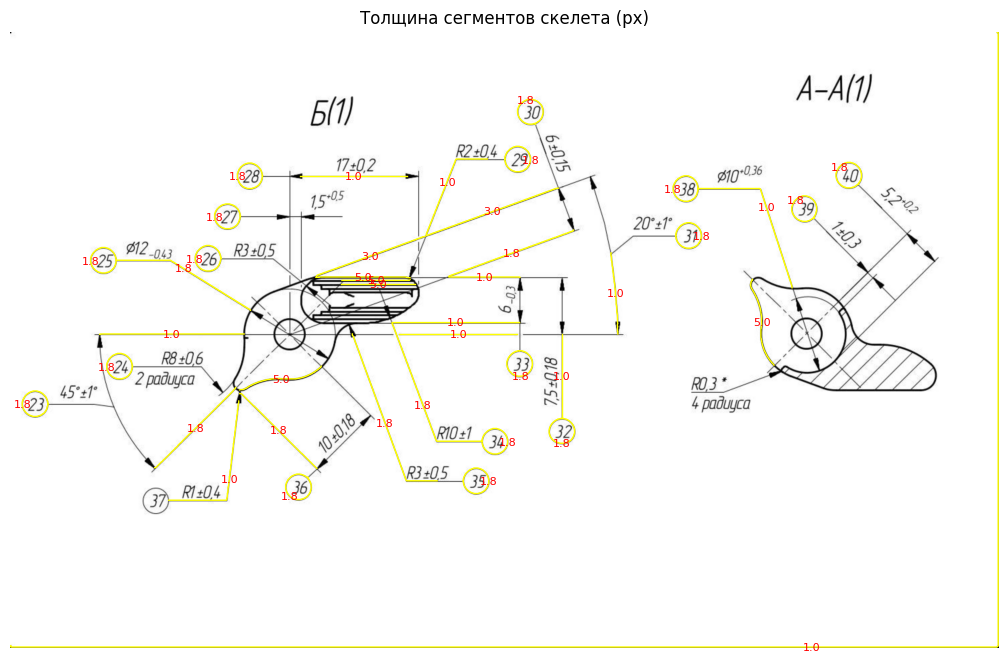

In [ ]:
plt.figure(figsize=(16, 8))
plt.imshow(resized[..., ::-1])
for i in range(skeleton.n_paths):
    coords = skeleton.path_coordinates(i)
    if len(coords) < 200:  # мусорные обрубки не подписываем
        continue
    mid = coords[len(coords) // 2]
    plt.plot(coords[:, 1], coords[:, 0], color="yellow", linewidth=1.0)
    plt.text(
        mid[1], mid[0], f"{summary['thickness'].to_numpy()[i]:.1f}", color="red", fontsize=8, ha="center", va="center"
    )
plt.axis("off")
plt.title("Толщина сегментов скелета (px)")
plt.show()


In [ ]:
res = ui_merge.result
chain, ext, agg = res["chain"], res["ext"], res["agg"]
t = agg["t"].to_numpy()
segments = [seg_xy[i] for i in ext]


def run_split(pct):
    """Синие — тоньше порога, красные — толще. Ручка: сколько процентов цепей уходит в синие."""
    thr = np.nanpercentile(t, pct)
    thick = t > thr
    colors = np.where(thick[chain][:, None], (0.95, 0.25, 0.25), (0.25, 0.45, 0.95))

    print(f"{pct:.0f}% цепей -> порог {thr:.1f} px ({thr / SCALE:.1f} px оригинала)")
    print(f"синих {int((~thick).sum())} | красных {int(thick.sum())} из {len(t)}")

    fig, ax = plt.subplots(figsize=(18, 10))
    ax.imshow(resized[..., ::-1])
    ax.add_collection(LineCollection(segments, colors=colors, linewidths=1.4))
    ax.axis("off")
    ax.set_title(f"{pct:.0f}% = {thr:.1f} px: синие ниже, красные выше")
    plt.show()
    return thr


ui_split = interactive(
    run_split,
    pct=FloatSlider(value=50, min=0, max=100, step=1, continuous_update=False, description="порог, %"),
)
ui_split


interactive(children=(FloatSlider(value=50.0, continuous_update=False, description='порог, %', step=1.0), Outp…

In [ ]:
res = ui_merge.result
chain, ext, agg = res["chain"], res["ext"], res["agg"]
segments = [seg_xy[i] for i in ext]

t, w = agg["t"].to_numpy(), agg["len"].to_numpy()
ok = np.isfinite(t)


def run_kmeans(k, weighted):
    """Классы толщины через 1-D KMeans. Нумерация — по возрастанию толщины."""
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(t[ok, None], sample_weight=w[ok] if weighted else None)
    order = np.argsort(km.cluster_centers_.ravel())
    rank = np.empty(k, int)
    rank[order] = np.arange(k)
    centers = km.cluster_centers_.ravel()[order]
    edges = (centers[:-1] + centers[1:]) / 2
    cls = np.full(len(t), -1, int)
    cls[ok] = rank[km.labels_]

    print(f"центры, px:  {np.round(centers, 2)} | в оригинале {np.round(centers / SCALE, 2)}")
    print(f"границы, px: {np.round(edges, 2)} | в оригинале {np.round(edges / SCALE, 2)}")
    for c in range(k):
        m = cls == c
        print(
            f"класс {c}: цепей {int(m.sum())} | длина {w[m].sum() / w[ok].sum():.1%} | t от {t[m].min():.1f} до {t[m].max():.1f}"
        )

    colors = np.array(PALETTE[:k], float) / 255
    fig, ax = plt.subplots(figsize=(18, 10))
    ax.imshow(resized[..., ::-1])
    ax.add_collection(LineCollection(segments, colors=colors[cls.clip(0)[chain]], linewidths=1.2))
    ax.axis("off")
    ax.set_title(f"{k} классов | границы {np.round(edges, 1)} px ({np.round(edges / SCALE, 1)} оригинала)")
    plt.show()
    return cls, centers, edges


ui_cls = interactive(
    run_kmeans,
    k=IntSlider(value=2, min=2, max=6, step=1, continuous_update=False, description="классов"),
    weighted=True,
)
ui_cls


interactive(children=(IntSlider(value=2, continuous_update=False, description='классов', max=6, min=2), Checkb…